# Concept swaps in J-lens coordinates — GPT-2 XL

Replace the model's representation of one concept with another's in J-lens coordinates and
check that the answer changes accordingly, as in the paper's two-hop and flexible-generalization
swaps (`data/experiments/probe-swap.json`, `flexible-generalization.json`). Example:
*"The capital of France is the city of"* with France → China should answer *Beijing*.
The paper's two-hop prompts are too hard for GPT-2 XL (17% answered), so we add
`latent-bridge.json`: *"The Eiffel Tower is in a country where the main language is"* — the
country is never named, and swapping France → Japan should answer *Japanese*.

**Answer (this run, §3).** J-lens swaps work on GPT-2 XL and are specific. On the latent-bridge
set (284 of 400 trials answered correctly) the best setting flips 88% of answers to the swapped
country's language (α = 2, band 16–40; 95% CI 84–92%), with random directions of the same size at
≤ 4%. On the paper's sets up to 68% of flexible-generalization and 47% of two-hop swaps flip
(random ≤ 8%). Without J (logit-lens directions) swaps fail in early and middle layers; there the
J-lens directions are what carries the concept.

## Method

**Lens vectors.** The J-lens logit of token t at layer l is `u_tᵀ C(γ ⊙ J_l h)/σ` (`u_t`: the
unembedding row; `γ`, `C`: the `ln_f` gain and centering; `σ` is shared by all tokens). Its
direction in the residual stream is `v_t = J_lᵀ C(γ ⊙ u_t)` — a row of `W_U J_l` with the final
norm folded in. The logit-lens control uses `J_l = I`.

**Swap (clamping).** For source s and target t, `V = [v_s v_t]` and coordinates `c = V⁺h`. A
clean pass records `c_clean` at every band layer and position; the patched pass sets, after
each band block, `h ← h + V(c* − V⁺h)` with `c* = c_clean + α(swap(c_clean) − c_clean)`. At
α = 1 the two coordinates are exchanged; the component of h orthogonal to `span(V)` is kept.
All prompt positions except BOS are patched, as in the paper (*"at every token position across
a band of intermediate layers"*).

Clamping matters with a band: applying the swap `h + αV(swap(c) − c)` to the already patched
stream at each layer undoes it at every second layer (the coordinates carried over are
swapped back), and with α > 1 the overshoot compounds.

**Grid.** Bands of block outputs 8–16, 16–24, 24–32, 32–40, 40–47, 12–36, 16–40 (GPT-2 XL has
no published workspace band); α ∈ {1, 2, 4}; directions `J`, `logit`, and `random` (each
position's J-swap update norm in a random direction).

**Batching.** Trials are grouped by length, right-padded, and run 64 at a time; GPT-2 is
causal, so no attention mask is needed and each row is read at its last real token. Each row
carries its own basis `V` and clean activations.

**Success.** The next-token top-1 is a spelling of the swap answer. Reported over all trials
and over trials the model answers correctly without intervention, with Wilson 95% intervals.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm

import jlens
from gpt2 import GPT2LensModel
from jlens.evaluation import spelling_ids
from jlens.hooks import ActivationRecorder

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
LENS_PATH = RUN_DIR / "snapshot_lens_134.pt"
OUT_DIR = RUN_DIR / "swap"
CACHES = {"swap_trials.csv": ["probe-swap", "flexible"], "swap_trials_latent-bridge.csv": ["latent-bridge"]}
SETS = ["flexible", "probe-swap", "latent-bridge"]
BANDS = ["8-16", "16-24", "24-32", "32-40", "40-47", "12-36", "16-40"]  # half-open block-output ranges
ALPHAS = [1.0, 2.0, 4.0]
MODES = ["J", "logit", "random"]
BATCH_SIZE = 64  # trials per forward pass
OUT_DIR.mkdir(parents=True, exist_ok=True)
torch.manual_seed(0)

## 1. Trials

In [4]:
def load_trials() -> pd.DataFrame:
    trials = []
    for name in ("probe-swap", "latent-bridge"):
        for item in json.load(open(Path(REPO_DIR) / f"data/experiments/{name}.json"))["items"]:
            trials.append({"set": name, "group": item["category"], "name": item["name"],
                           "prompt": item["prompt"].rstrip(), "source": item["intermediate"],
                           "target": item["swap_to"], "answer": item["answer"], "swap_answer": item["swap_answer"]})
    for category in json.load(open(Path(REPO_DIR) / "data/experiments/flexible-generalization.json"))["categories"]:
        for func in category["funcs"]:
            for source in category["args"]:
                for target in category["args"]:
                    if target != source:
                        trials.append({
                            "set": "flexible", "group": f"{category['name']}/{func['name']}",
                            "name": f"{func['name']}:{source}->{target}",
                            "prompt": func["template"].format(arg=source).rstrip(), "source": source,
                            "target": target, "answer": func["answers"][source],
                            "swap_answer": func["answers"][target]})
    return pd.DataFrame(trials)


trials = load_trials()
display(trials.groupby("set").size().to_frame("trials"))
trials.groupby("set").head(2)[["set", "prompt", "source", "target", "answer", "swap_answer"]]

,trials
set,
flexible,192
latent-bridge,400
probe-swap,90


,set,prompt,source,target,answer,swap_answer
0,probe-swap,Fact: The language spoken in the country where...,Brazil,Mexico,Portuguese,Spanish
1,probe-swap,Fact: The hard covering on the back of the slo...,turtle,snake,shell,scale
90,latent-bridge,The Eiffel Tower is in a country where the mai...,France,Peru,French,Spanish
91,latent-bridge,The Eiffel Tower is in a country where the mai...,France,Poland,French,Polish
490,flexible,The capital of France is the city of,France,Canada,Paris,Ottawa
491,flexible,The capital of France is the city of,France,China,Paris,Beijing


## 2. Run

Each file in `CACHES` is skipped when it exists (~1.5 min on a V100 for the 282 paper trials and
~2 min for the 400 latent-bridge trials, × 63 settings each).

In [5]:
missing = {name: sets for name, sets in CACHES.items() if not (OUT_DIR / name).exists()}
if missing:
    model = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
    tok = model.tokenizer
    lens = jlens.JacobianLens.load(str(LENS_PATH))
    jacobians = {layer: J.to(DEVICE) for layer, J in lens.jacobians.items()}
    W_U = model._lm_head.weight.float()
    gamma = model._final_norm.weight.float()

    def concept_token(word):
        ids = tok.encode(" " + word, add_special_tokens=False)
        return ids[0], len(ids) == 1

    trials["source_id"], trials["source_single"] = zip(*trials.source.map(concept_token), strict=True)
    trials["target_id"], trials["target_single"] = zip(*trials.target.map(concept_token), strict=True)

    class Bases:
        """Per-row V = [v_s v_t] (stored transposed, [batch, 2, d]) and pseudoinverses, cached by (layer, kind)."""

        def __init__(self, source_ids, target_ids):
            g = gamma * W_U[torch.stack([source_ids, target_ids], 1)]  # [batch, 2, d]
            self.unembed = g - g.mean(-1, keepdim=True)
            self.cache = {}

        def __call__(self, layer, mode):
            key = (layer, "logit" if mode == "logit" else "J")  # random mode uses the J basis for the update norm
            if key not in self.cache:
                Vt = self.unembed if key[1] == "logit" else self.unembed @ jacobians[layer]
                self.cache[key] = (Vt, torch.linalg.pinv(Vt.transpose(1, 2)))
            return self.cache[key]

    class Swap:
        """Clamp each row's (source, target) lens coordinates at every hooked layer to swapped clean values."""

        def __init__(self, layers, bases, alpha, mode, clean):
            self.bases, self.alpha, self.mode, self.clean = bases, alpha, mode, clean
            self.handles = [model.layers[layer].register_forward_hook(self.hook(layer)) for layer in layers]

        def hook(self, layer):
            def fn(module, inputs, output):
                h = output if torch.is_tensor(output) else output[0]
                Vt, V_pinv = self.bases(layer, self.mode)
                c = torch.einsum("btd,bkd->btk", h[:, 1:].float(), V_pinv)  # BOS skipped
                c_clean = torch.einsum("btd,bkd->btk", self.clean[layer][:, 1:].float(), V_pinv)
                target = c_clean + self.alpha * (c_clean[..., [1, 0]] - c_clean)
                update = torch.einsum("btk,bkd->btd", target - c, Vt)
                if self.mode == "random":
                    direction = torch.randn_like(update)
                    update = direction / direction.norm(dim=-1, keepdim=True) * update.norm(dim=-1, keepdim=True)
                h = h.clone()
                h[:, 1:] += update.to(h.dtype)
                return h if torch.is_tensor(output) else (h, *output[1:])
            return fn

        def __enter__(self):
            return self

        def __exit__(self, *exc):
            for handle in self.handles:
                handle.remove()

    answer_ids = {}

    def answer_mask(words):
        """[batch, vocab] mask of each row's answer spellings."""
        mask = torch.zeros(len(words), W_U.shape[0], dtype=torch.bool, device=DEVICE)
        for row, word in enumerate(words):
            if word not in answer_ids:
                answer_ids[word] = sorted(spelling_ids(tok, word))
            mask[row, answer_ids[word]] = True
        return mask

    @torch.no_grad()
    def next_token_logits(ids, last):
        # Right padding needs no attention mask: GPT-2 is causal and each row is read at its last real token.
        hidden = model.forward(ids).last_hidden_state  # ln_f already applied
        return model._lm_head(hidden[torch.arange(len(ids), device=DEVICE), last]).float()

    def ranks(logits, mask):
        best = logits.masked_fill(~mask, -torch.inf).max(-1, keepdim=True).values
        return (logits > best).sum(-1) + 1

    for name, sets in missing.items():
        rows = []
        subset = trials[trials.set.isin(sets)]
        encoded = [model.encode(prompt)[0] for prompt in subset.prompt]
        order = np.argsort([len(ids) for ids in encoded], kind="stable")  # similar lengths share a batch
        for start in tqdm(range(0, len(order), BATCH_SIZE), desc=name):
            index = order[start:start + BATCH_SIZE]
            chunk = subset.iloc[index]
            ids = torch.nn.utils.rnn.pad_sequence([encoded[i] for i in index], batch_first=True,
                                                  padding_value=tok.eos_token_id)
            last = torch.tensor([len(encoded[i]) - 1 for i in index], device=DEVICE)
            answer, swap_answer = answer_mask(chunk.answer), answer_mask(chunk.swap_answer)
            with ActivationRecorder(model.layers, at=range(model.n_layers - 1)) as recorder:
                base = next_token_logits(ids, last)
            clean = {layer: activation.detach() for layer, activation in recorder.activations.items()}
            bases = Bases(torch.tensor(chunk.source_id.values, device=DEVICE),
                          torch.tensor(chunk.target_id.values, device=DEVICE))
            base_top1 = base.argmax(-1)
            base_rows = [{**trial.drop(["prompt"]).to_dict(), "base_top1": tok.decode([top]),
                          "base_correct": correct, "base_rank_swap": rank}
                         for (_, trial), top, correct, rank in zip(
                             chunk.iterrows(), base_top1.tolist(),
                             answer[torch.arange(len(index)), base_top1].tolist(),
                             ranks(base, swap_answer).tolist(), strict=True)]
            for band in BANDS:
                layer_start, layer_stop = map(int, band.split("-"))
                for mode in MODES:
                    for alpha in ALPHAS:
                        with Swap(range(layer_start, layer_stop), bases, alpha, mode, clean):
                            patched = next_token_logits(ids, last)
                        top1 = patched.argmax(-1)
                        for row, top, success, rank_swap, rank_answer in zip(
                                base_rows, top1.tolist(), swap_answer[torch.arange(len(index)), top1].tolist(),
                                ranks(patched, swap_answer).tolist(), ranks(patched, answer).tolist(), strict=True):
                            rows.append({**row, "band": band, "mode": mode, "alpha": alpha,
                                         "top1": tok.decode([top]), "success": success,
                                         "rank_swap": rank_swap, "rank_answer": rank_answer})
        pd.DataFrame(rows).to_csv(OUT_DIR / name, index=False)
    del model, jacobians
results = pd.concat([pd.read_csv(OUT_DIR / name) for name in CACHES], ignore_index=True)
print(len(results), "rows")

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

swap_trials.csv:   0%|          | 0/5 [00:00<?, ?it/s]

swap_trials_latent-bridge.csv:   0%|          | 0/7 [00:00<?, ?it/s]

42966 rows


## 3. Results

### Baseline: does GPT-2 XL answer without intervention?

In [6]:
base = results.drop_duplicates(["set", "name"])
base.groupby("set").agg(trials=("base_correct", "size"), correct=("base_correct", "sum"),
                        accuracy=("base_correct", "mean")).round(3)

,trials,correct,accuracy
set,,,
flexible,192,63,0.328
latent-bridge,400,284,0.710
probe-swap,90,15,0.167


### Swap success over all trials

In [7]:
def success_table(frame):
    return frame.groupby(["set", "mode", "alpha", "band"]).success.mean().unstack("band")[BANDS].round(3)


success_table(results)

band                         8-16  16-24  24-32  32-40  40-47  12-36  16-40
set           mode   alpha                                                 
flexible      J      1.0    0.068  0.078  0.078  0.146  0.151  0.203  0.208
                     2.0    0.281  0.240  0.203  0.141  0.109  0.208  0.167
                     4.0    0.271  0.266  0.172  0.073  0.026  0.104  0.068
              logit  1.0    0.000  0.000  0.016  0.130  0.135  0.078  0.135
                     2.0    0.000  0.000  0.125  0.109  0.109  0.125  0.109
                     4.0    0.005  0.052  0.109  0.042  0.026  0.052  0.042
              random 1.0    0.000  0.016  0.005  0.010  0.010  0.016  0.010
                     2.0    0.031  0.021  0.005  0.026  0.010  0.031  0.031
                     4.0    0.016  0.031  0.026  0.010  0.016  0.026  0.010
latent-bridge J      1.0    0.068  0.110  0.230  0.507  0.430  0.470  0.568
                     2.0    0.280  0.440  0.660  0.720  0.655  0.715  0.755
                     4.0    0.500  0.612  0.742  0.558  0.392  0.718  0.562
              logit  1.0    0.018  0.018  0.072  0.470  0.435  0.292  0.485
                     2.0    0.022  0.040  0.472  0.680  0.625  0.648  0.690
                     4.0    0.055  0.175  0.658  0.458  0.375  0.618  0.442
              random 1.0    0.020  0.018  0.015  0.012  0.015  0.022  0.015
                     2.0    0.020  0.018  0.018  0.022  0.028  0.045  0.040
                     4.0    0.030  0.032  0.035  0.028  0.022  0.040  0.030
probe-swap    J      1.0    0.011  0.011  0.022  0.056  0.022  0.067  0.078
                     2.0    0.078  0.089  0.111  0.089  0.078  0.100  0.111
                     4.0    0.111  0.122  0.100  0.033  0.044  0.056  0.033
              logit  1.0    0.000  0.011  0.011  0.067  0.022  0.022  0.067
                     2.0    0.000  0.011  0.022  0.067  0.067  0.089  0.078
                     4.0    0.011  0.011  0.089  0.033  0.044  0.033  0.033
              random 1.0    0.011  0.011  0.000  0.011  0.011  0.011  0.011
                     2.0    0.011  0.011  0.000  0.011  0.022  0.033  0.011
                     4.0    0.000  0.011  0.000  0.022  0.011  0.000  0.000

### Swap success over baseline-correct trials

Only trials the model answers correctly can show that the swap moves the *computed* answer.
Wilson 95% intervals for the best setting of each direction:

In [8]:
correct = results[results.base_correct]
display(success_table(correct))


def wilson(successes, n, z=1.96):
    p = successes / n
    centre = (p + z**2 / (2 * n)) / (1 + z**2 / n)
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return centre - half, centre + half


grouped = correct.groupby(["set", "mode", "alpha", "band"]).success.agg(["sum", "size"]).reset_index()
best = grouped.loc[grouped.groupby(["set", "mode"])["sum"].idxmax()].copy()
best["rate"] = best["sum"] / best["size"]
best["CI lo"], best["CI hi"] = wilson(best["sum"], best["size"])
best.round(3)

band                         8-16  16-24  24-32  32-40  40-47  12-36  16-40
set           mode   alpha                                                 
flexible      J      1.0    0.175  0.206  0.222  0.397  0.413  0.492  0.508
                     2.0    0.683  0.571  0.508  0.349  0.254  0.476  0.397
                     4.0    0.603  0.603  0.397  0.127  0.079  0.206  0.127
              logit  1.0    0.000  0.000  0.048  0.365  0.365  0.222  0.381
                     2.0    0.000  0.000  0.333  0.302  0.238  0.349  0.302
                     4.0    0.016  0.111  0.302  0.111  0.079  0.143  0.127
              random 1.0    0.000  0.000  0.000  0.000  0.000  0.000  0.032
                     2.0    0.048  0.032  0.000  0.032  0.032  0.063  0.063
                     4.0    0.032  0.079  0.048  0.016  0.000  0.048  0.016
latent-bridge J      1.0    0.053  0.120  0.278  0.620  0.528  0.585  0.687
                     2.0    0.345  0.539  0.817  0.863  0.771  0.859  0.884
                     4.0    0.588  0.715  0.849  0.570  0.352  0.778  0.577
              logit  1.0    0.000  0.004  0.074  0.581  0.535  0.356  0.595
                     2.0    0.007  0.032  0.599  0.810  0.729  0.789  0.820
                     4.0    0.042  0.201  0.792  0.465  0.352  0.704  0.444
              random 1.0    0.000  0.000  0.000  0.000  0.000  0.004  0.007
                     2.0    0.000  0.000  0.011  0.018  0.011  0.039  0.021
                     4.0    0.025  0.018  0.025  0.021  0.014  0.032  0.014
probe-swap    J      1.0    0.000  0.000  0.067  0.200  0.067  0.267  0.333
                     2.0    0.333  0.333  0.333  0.267  0.133  0.333  0.333
                     4.0    0.333  0.467  0.333  0.067  0.067  0.200  0.067
              logit  1.0    0.000  0.000  0.000  0.200  0.067  0.067  0.200
                     2.0    0.000  0.000  0.067  0.200  0.133  0.333  0.200
                     4.0    0.000  0.000  0.200  0.067  0.067  0.067  0.067
              random 1.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000
                     2.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000
                     4.0    0.000  0.000  0.000  0.000  0.000  0.000  0.000

,set,mode,alpha,band,sum,size,rate,CI lo,CI hi
13,flexible,J,2.0,8-16,43,63,0.683,0.560,0.784
23,flexible,logit,1.0,16-40,24,63,0.381,0.271,0.504
57,flexible,random,4.0,16-24,5,63,0.079,0.034,0.173
72,latent-bridge,J,2.0,16-40,251,284,0.884,0.841,0.916
93,latent-bridge,logit,2.0,16-40,233,284,0.820,0.772,0.861
112,latent-bridge,random,2.0,12-36,11,284,0.039,0.022,0.068
141,probe-swap,J,4.0,16-24,7,15,0.467,0.248,0.699
154,probe-swap,logit,2.0,12-36,5,15,0.333,0.152,0.583
168,probe-swap,random,1.0,12-36,0,15,0.000,-0.000,0.204


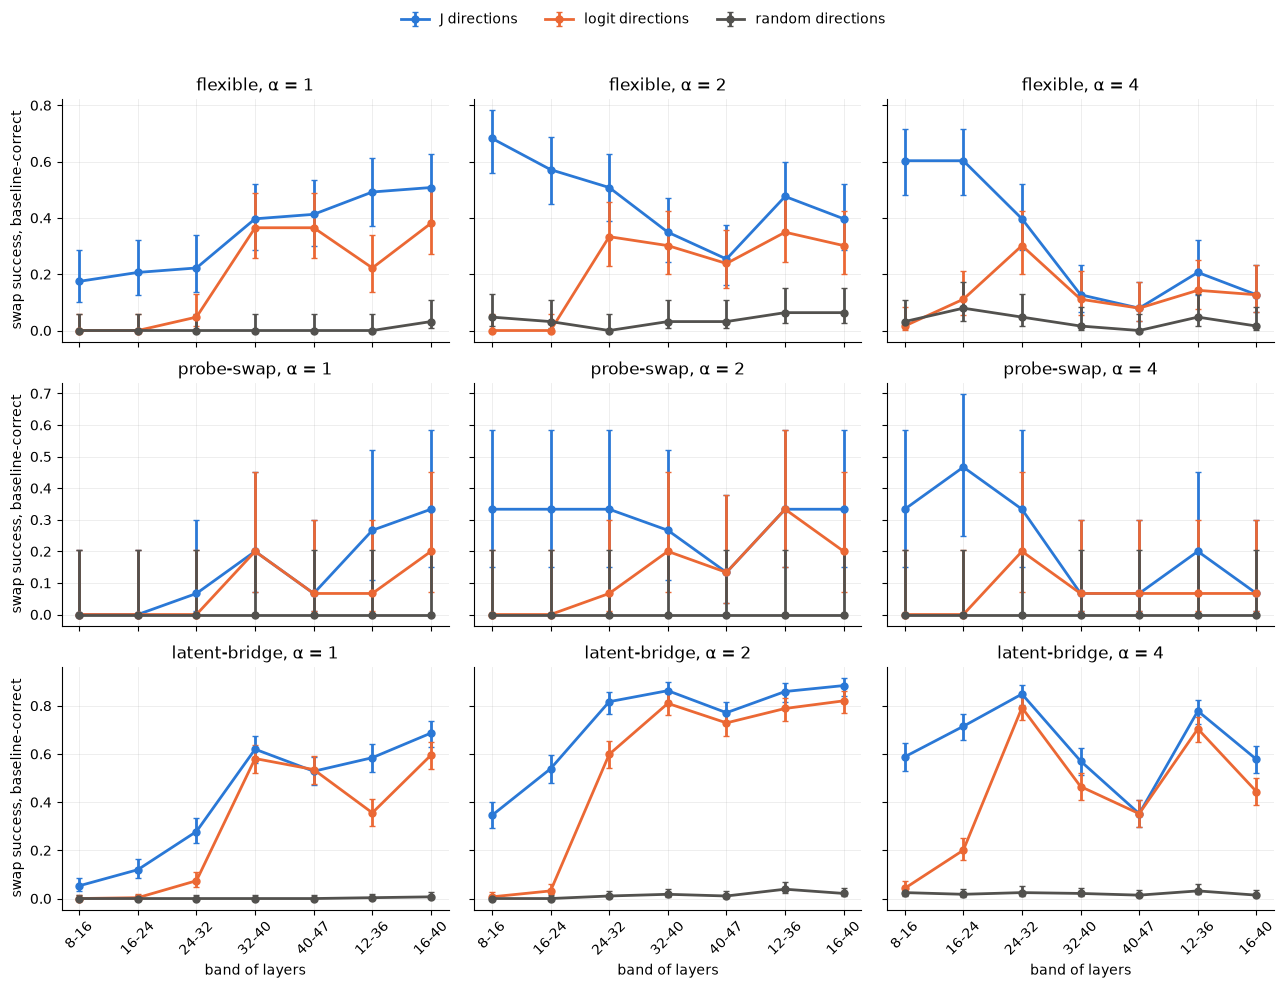

In [9]:
COLORS = {"J": "#2a78d6", "logit": "#eb6834", "random": "#52514e"}
fig, axes = plt.subplots(len(SETS), 3, figsize=(13, 3.3 * len(SETS)), sharex=True, sharey="row")
for row_axes, name in zip(axes, SETS, strict=True):
    for ax, alpha in zip(row_axes, ALPHAS, strict=True):
        for mode, color in COLORS.items():
            sub = grouped[(grouped.set == name) & (grouped["mode"] == mode) & (grouped.alpha == alpha)]
            sub = sub.set_index("band").loc[BANDS]
            rate = sub["sum"] / sub["size"]
            lo, hi = wilson(sub["sum"], sub["size"])
            ax.errorbar(range(len(BANDS)), rate, yerr=[rate - lo, hi - rate], color=color, marker="o", ms=5,
                        lw=2, capsize=2, label=f"{mode} directions")
        ax.set_title(f"{name}, α = {alpha:g}")
        ax.grid(alpha=0.25, lw=0.6)
        ax.spines[["top", "right"]].set_visible(False)
    row_axes[0].set_ylabel("swap success, baseline-correct")
for ax in axes[-1]:
    ax.set_xticks(range(len(BANDS)), BANDS, rotation=45)
    ax.set_xlabel("band of layers")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

### Median log10 rank gain of the swap answer (all trials)

In [10]:
results["log10 rank gain"] = np.log10(results.base_rank_swap) - np.log10(results.rank_swap)
results.groupby(["set", "mode", "alpha", "band"])["log10 rank gain"].median().unstack("band")[BANDS].round(2)

band                        8-16  16-24  24-32  32-40  40-47  12-36  16-40
set           mode   alpha                                                
flexible      J      1.0    0.23   0.22   0.17   0.25   0.30   0.31   0.30
                     2.0    0.47   0.41   0.31   0.33   0.40   0.48   0.45
                     4.0    0.60   0.49   0.48   0.31   0.37   0.42   0.35
              logit  1.0    0.00   0.00   0.08   0.19   0.27   0.13   0.18
                     2.0    0.00   0.01   0.14   0.30   0.37   0.23   0.29
                     4.0    0.01   0.05   0.21   0.30   0.38   0.27   0.27
              random 1.0    0.02   0.00   0.00   0.00  -0.02   0.03   0.00
                     2.0    0.09   0.06   0.03  -0.07  -0.20   0.13  -0.05
                     4.0    0.12   0.10   0.00  -0.36  -0.47  -0.36  -0.62
latent-bridge J      1.0    0.26   0.52   0.85   1.05   1.04   1.04   1.11
                     2.0    0.64   0.90   1.18   1.25   1.24   1.25   1.27
                     4.0    0.99   1.18   1.32   1.25   1.26   1.32   1.28
              logit  1.0    0.00   0.06   0.53   1.04   1.05   0.85   1.05
                     2.0    0.04   0.15   1.02   1.23   1.23   1.20   1.23
                     4.0    0.11   0.42   1.20   1.22   1.22   1.30   1.21
              random 1.0    0.00   0.00   0.00   0.00  -0.01   0.02   0.00
                     2.0    0.01   0.03   0.04  -0.02  -0.13   0.12   0.02
                     4.0    0.12   0.16   0.15  -0.33  -0.40  -0.02  -0.36
probe-swap    J      1.0    0.02   0.02   0.04   0.06   0.04   0.07   0.04
                     2.0    0.07   0.07   0.07   0.11   0.11   0.12   0.08
                     4.0    0.13   0.14   0.10   0.11   0.18   0.15   0.10
              logit  1.0    0.00   0.00   0.04   0.06   0.06   0.07   0.07
                     2.0    0.00   0.01   0.08   0.12   0.12   0.12   0.12
                     4.0    0.00   0.03   0.10   0.16   0.20   0.12   0.14
              random 1.0    0.00   0.00   0.00  -0.00   0.00   0.00  -0.01
                     2.0    0.02   0.01   0.00  -0.01  -0.02   0.06  -0.01
                     4.0    0.00   0.04  -0.02  -0.08  -0.09  -0.15  -0.09

## 4. Conclusions

* **J-lens swaps move the computed answer.** On the latent-bridge set, where the swapped country
  is never named in the prompt, the best setting flips 88% of baseline-correct trials (251/284,
  α = 2, band 16–40; 76% of all 400 trials). On the paper's sets the best settings flip 68% of
  flexible-generalization trials (α = 2, band 8–16) and 47% of two-hop trials (α = 4, band 16–24;
  only 15 such trials). The paper reports 76/192 flexible swaps at α = 1 and 101/192 at α = 2 for
  much larger models.
* **Specific to the lens directions.** Random directions with the same per-position update norm
  succeed in ≤ 4% of baseline-correct latent-bridge trials and ≤ 8% on the paper's sets.
* **J matters in early and middle layers.** On latent-bridge, bands 8–16 and 16–24 give 59% and
  72% with J directions at α = 4 but 4% and 20% with logit-lens directions; from layer ~24–32 on,
  where `J_l` is close to the identity, the two agree within ~5–20 points. The flexible set shows
  the same pattern (logit 0% at bands 8–24, α ≤ 2).
* **Strength vs depth.** Early bands need α = 2–4; late bands work best at α = 1–2 and degrade
  with larger α (latent-bridge 40–47: 77% at α = 2, 35% at α = 4).
* **Latent-bridge is a usable two-hop test for GPT-2 XL.** GPT-2 XL answers 71% of its prompts
  (vs 17% of `probe-swap`), so the baseline-correct set is large enough for tight intervals.
  Misses concentrate on less famous landmarks and smaller countries (Thailand, Poland, Israel,
  Portugal).
* **Caveats.** A correct answer does not prove the model routes through the country: it may map
  a landmark to a language directly, and the swap shows only that the country's lens direction
  can redirect the answer. Bands were chosen as a grid, not from a measured workspace band; the
  random control differs between runs because of the random draw.